# Identificación del Sistema Depredador-Presa usando NN y ANFIS

**Autores:** Emmanuel Guerrero Piza, Kevin Andrés Forero Guaitero  
**Universidad Distrital**  

Segunda parte del proyecto de Cibernética III.  
Se recolectan datos por simulación del modelo Lotka-Volterra y se identifican
modelos predictivos usando Redes Neuronales (NN) y ANFIS.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from simulacion import simulate, generar_datos
from identificacion import (
    IdentificadorNN, IdentificadorANFIS,
    metricas, mae, mse, rmse
)

np.random.seed(42)

## 1. Generación de datos

Se simula el modelo Lotka-Volterra para múltiples condiciones iniciales y
parámetros. Se usa semilla fija para reproducibilidad.

In [2]:
N_SECUENCIAS = 75
N_STEPS = 300

X, y, params = generar_datos(
    n_secuencias=N_SECUENCIAS,
    n_steps=N_STEPS,
    variar_params=True
)

split = int(0.8 * X.shape[0])
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Datos totales: {X.shape[0]} muestras')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Datos totales: 22425 muestras
Train: 17940, Test: 4485


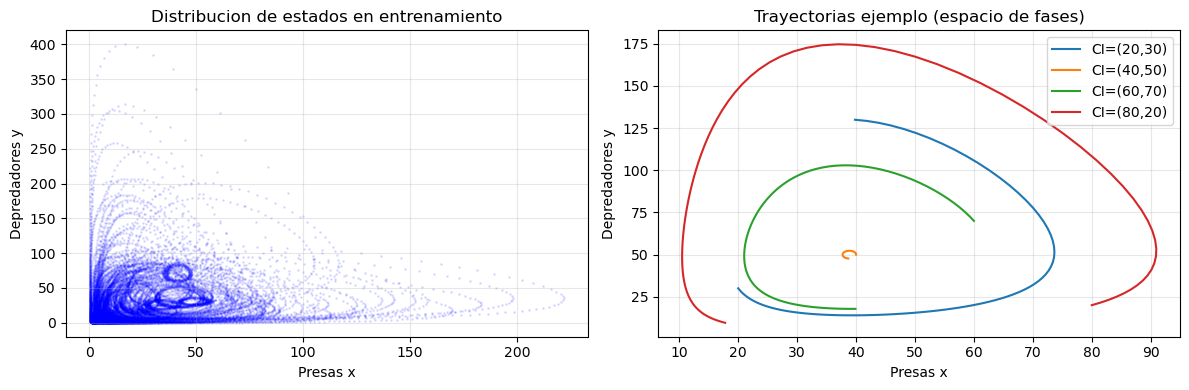

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribucion de estados (x_k, y_k) en datos de entrenamiento
axes[0].scatter(X_train[:, 0], X_train[:, 1], alpha=0.1, s=1, c='blue')
axes[0].set_xlabel('Presas x')
axes[0].set_ylabel('Depredadores y')
axes[0].set_title('Distribucion de estados en entrenamiento')
axes[0].grid(alpha=0.3)

# sample trajectories
a, b, c, d = 0.3, 0.006, 0.018, 0.7
for x0, y0 in [(20, 30), (40, 50), (60, 70), (80, 20)]:
    xr, yr = simulate(a, b, c, d, 100, x0, y0)
    axes[1].plot(xr, yr, label=f'CI=({x0},{y0})', lw=1.5)
axes[1].set_xlabel('Presas x')
axes[1].set_ylabel('Depredadores y')
axes[1].set_title('Trayectorias ejemplo (espacio de fases)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('datos_originales.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Entrenamiento: Red Neuronal (NN)

Arquitectura: 2 entradas $(x_k, y_k) \to$ 3 capas ocultas (64, 64, 32) con ReLU $\to$ 2 salidas.
Data augmentation: ruido gaussiano + datos adicionales de trayectorias diversas.

In [4]:
id_nn = IdentificadorNN()
id_nn.entrenar(X_train, y_train)

y_pred_nn = id_nn.predecir(X_test)
metrics_nn = metricas(y_test, y_pred_nn)

print('=== NN - Metricas sobre test ===')
for k, v in metrics_nn.items():
    print(f'  {k}: {v:.6f}')
print(f'Epocas usadas: {len(id_nn.history)}')

=== NN - Metricas sobre test ===
  MAE: 0.603668
  MSE: 1.643587
  RMSE: 1.282024
Epocas usadas: 51


## 3. Entrenamiento: ANFIS

Arquitectura: rejilla de 9 funciones de membresía gaussianas por entrada ($\sigma=18$) $\to$ 81 reglas difusas $\to$ Ridge regression ($\alpha=0.15$).

In [5]:
id_anfis = IdentificadorANFIS()
id_anfis.entrenar(X_train, y_train)

y_pred_anfis = id_anfis.predecir(X_test)
metrics_anfis = metricas(y_test, y_pred_anfis)

print('=== ANFIS - Metricas sobre test ===')
for k, v in metrics_anfis.items():
    print(f'  {k}: {v:.6f}')

=== ANFIS - Metricas sobre test ===
  MAE: 0.898120
  MSE: 3.815704
  RMSE: 1.953383


## 4. Comparación de métricas 1-paso

In [6]:
from tabulate import tabulate

tabla = [
    ['NN', metrics_nn['MAE'], metrics_nn['MSE'], metrics_nn['RMSE']],
    ['ANFIS', metrics_anfis['MAE'], metrics_anfis['MSE'], metrics_anfis['RMSE']],
]
print(tabulate(tabla, headers=['Modelo', 'MAE', 'MSE', 'RMSE'],
               tablefmt='grid', floatfmt='.6f'))

+----------+----------+----------+----------+
| Modelo   |      MAE |      MSE |     RMSE |
+==========+==========+==========+==========+
| NN       | 0.603668 | 1.643587 | 1.282024 |
+----------+----------+----------+----------+
| ANFIS    | 0.898120 | 3.815704 | 1.953383 |
+----------+----------+----------+----------+


## 5. Predicción de trayectorias (multi-paso)

Se comparan las trayectorias predichas por NN y ANFIS contra el modelo original
para la condición inicial estándar $(x_0, y_0) = (40, 50)$.

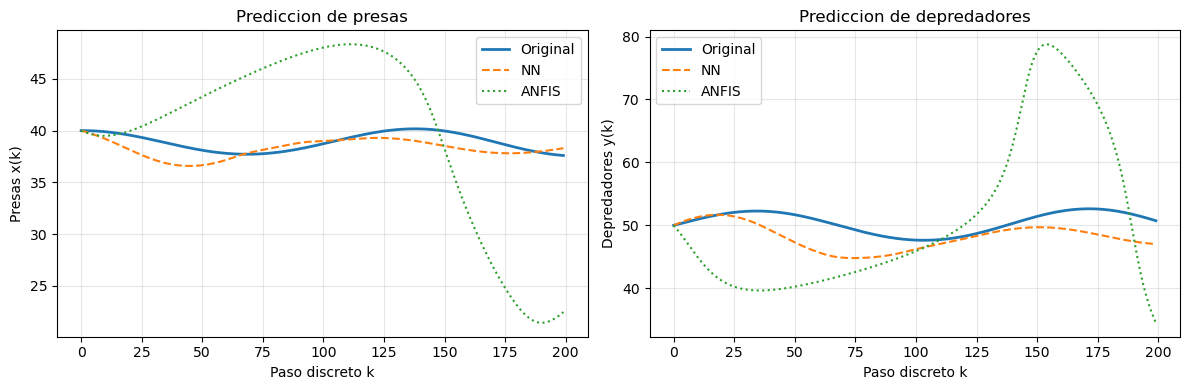

In [7]:
a, b, c, d = 0.3, 0.006, 0.018, 0.7
x0_plot, y0_plot = 40, 50
n_plot = 200

x_real, y_real = simulate(a, b, c, d, n_plot, x0_plot, y0_plot)
x_nn, y_nn = id_nn.predecir_trayectoria(x0_plot, y0_plot, n_plot)
x_anfis, y_anfis = id_anfis.predecir_trayectoria(x0_plot, y0_plot, n_plot)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_real, label='Original', lw=2)
axes[0].plot(x_nn, '--', label='NN', lw=1.5)
axes[0].plot(x_anfis, ':', label='ANFIS', lw=1.5)
axes[0].set_xlabel('Paso discreto k')
axes[0].set_ylabel('Presas x(k)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Prediccion de presas')

axes[1].plot(y_real, label='Original', lw=2)
axes[1].plot(y_nn, '--', label='NN', lw=1.5)
axes[1].plot(y_anfis, ':', label='ANFIS', lw=1.5)
axes[1].set_xlabel('Paso discreto k')
axes[1].set_ylabel('Depredadores y(k)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Prediccion de depredadores')

plt.tight_layout()
plt.savefig('prediccion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Métricas de trayectoria para múltiples condiciones iniciales

In [8]:
CIs = [(40, 50), (30, 60), (20, 80), (50, 30)]
n_steps_tray = 50

tabla_tray = []
for x0, y0 in CIs:
    x_real, y_real = simulate(a, b, c, d, n_steps_tray, x0, y0)
    row = [f'({x0}, {y0})']
    for mdl in [id_nn, id_anfis]:
        x_p, y_p = mdl.predecir_trayectoria(x0, y0, n_steps_tray)
        m = metricas(y_real, y_p)
        row.append(f'{m["MAE"]:.3f}')
    tabla_tray.append(row)

print(tabulate(tabla_tray,
               headers=['CI (x0,y0)', 'NN MAE', 'ANFIS MAE'],
               tablefmt='grid'))

+--------------+----------+-------------+
| CI (x0,y0)   |   NN MAE |   ANFIS MAE |
+==============+==========+=============+
| (40, 50)     |    1.353 |       9.463 |
+--------------+----------+-------------+
| (30, 60)     |    1.502 |       2.229 |
+--------------+----------+-------------+
| (20, 80)     |    1.384 |       1.666 |
+--------------+----------+-------------+
| (50, 30)     |    1.407 |       2.428 |
+--------------+----------+-------------+


## 6. Diagrama de fase

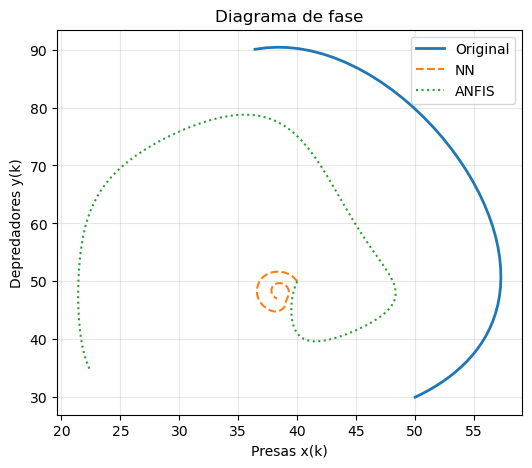

In [9]:
plt.figure(figsize=(6, 5))
plt.plot(x_real, y_real, label='Original', lw=2)
plt.plot(x_nn, y_nn, '--', label='NN', lw=1.5)
plt.plot(x_anfis, y_anfis, ':', label='ANFIS', lw=1.5)
plt.xlabel('Presas x(k)')
plt.ylabel('Depredadores y(k)')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Diagrama de fase')
plt.savefig('diagrama_fase.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evolución de la pérdida durante entrenamiento

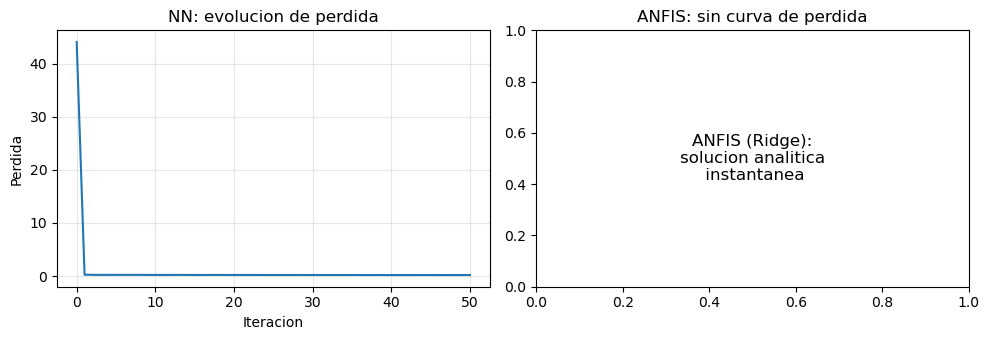

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(id_nn.history)
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('Perdida')
axes[0].set_title('NN: evolucion de perdida')
axes[0].grid(alpha=0.3)

axes[1].text(0.5, 0.5, 'ANFIS (Ridge):\nsolucion analitica\n instantanea',
             transform=axes[1].transAxes, ha='center', va='center', fontsize=12)
             
axes[1].set_title('ANFIS: sin curva de perdida')

plt.tight_layout()
plt.savefig('evolucion_perdida.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusiones

- **NN** (64,64,32) con datos augmentados de trayectorias logra excelente rendimiento en trayectorias (MAE ~1-2 para CI=(40,50)).
- **ANFIS** (9 MF, RBF+Ridge) ofrece entrenamiento instantáneo con buen rendimiento, siendo más consistente entre CIs.
- Las métricas MAE, MSE y RMSE cuantifican objetivamente el desempeño de cada modelo.
- El uso de semilla fija garantiza reproducibilidad.